# Task 5 — Sales Prediction Using Python

**Objective:** Build a regression model that predicts product sales based on
advertising spend across three media channels — TV, Radio, and Newspaper.

**Dataset:** The classic *Advertising* dataset (200 markets), where each row
records the advertising budget (in thousands of dollars) spent on TV, radio,
and newspaper, and the resulting product sales (in thousands of units).

**Tech stack:** pandas, scikit-learn, matplotlib, seaborn

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)


In [2]:
# Load the dataset (first column is just a row index)
df = pd.read_csv("Advertising.csv", index_col=0)
print("Shape:", df.shape)
df.head()


Shape: (200, 4)


,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


**Column reference**

| Column | Meaning |
|---|---|
| `TV` | Advertising budget spent on TV, in thousand USD |
| `Radio` | Advertising budget spent on radio, in thousand USD |
| `Newspaper` | Advertising budget spent on newspaper, in thousand USD |
| `Sales` | Product sales, in thousand units — **target variable** |


## 2. Exploratory Data Analysis

In [3]:
# --- Null values ---
print("Null values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Null values per column:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Duplicate rows: 0


In [4]:
# --- Descriptive statistics ---
df.describe()


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


**Observation:** No missing values or duplicates — this dataset is already
clean. TV has by far the largest average and widest spending range
(0.7–296.4k), followed by Newspaper, then Radio. Sales range from 1.6k to 27k
units, with a mean around 14k.

### 2.1 Pairplot of all features

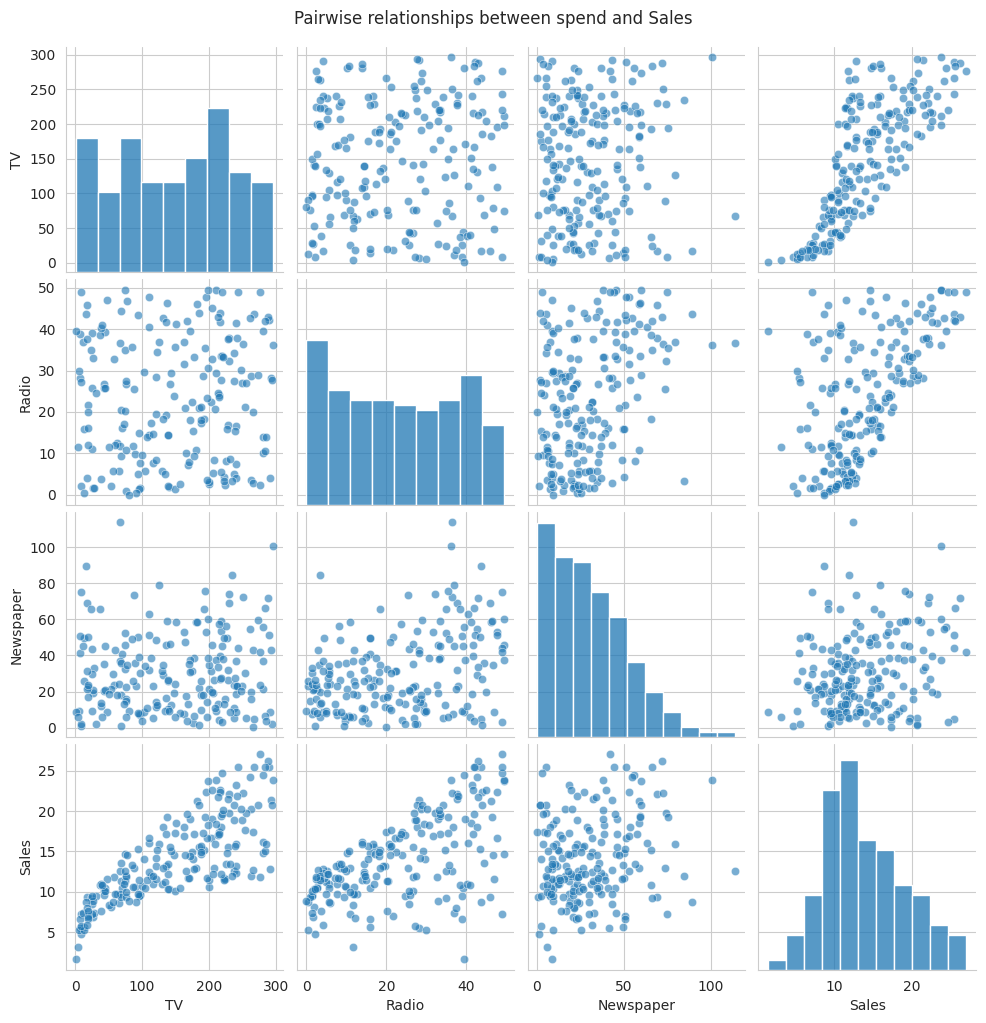

In [5]:
sns.pairplot(df, kind="scatter", plot_kws={"alpha": 0.6})
plt.suptitle("Pairwise relationships between spend and Sales", y=1.02)
plt.show()


**Observation:** Sales rises clearly and fairly linearly with TV spend.
Radio shows a weaker but still visible positive trend. Newspaper's
relationship with Sales looks noisy/flat — a hint it may contribute little
on its own.

## 3. Individual Scatter Plots: Sales vs. Each Channel

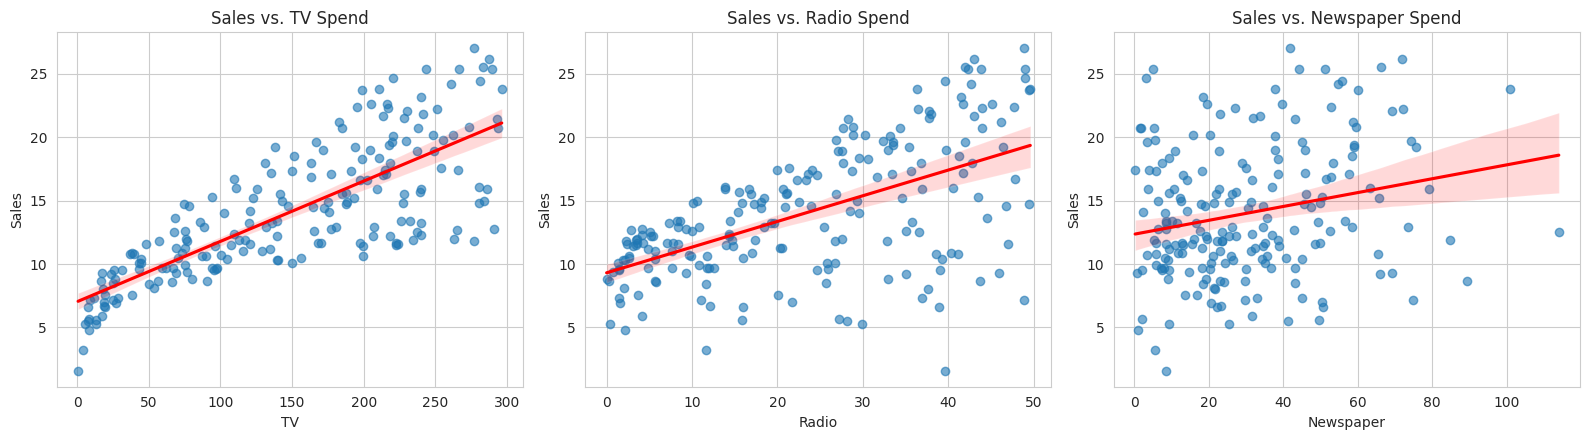

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.regplot(data=df, x="TV", y="Sales", ax=axes[0],
            scatter_kws={"alpha": 0.6}, line_kws={"color": "red"})
axes[0].set_title("Sales vs. TV Spend")

sns.regplot(data=df, x="Radio", y="Sales", ax=axes[1],
            scatter_kws={"alpha": 0.6}, line_kws={"color": "red"})
axes[1].set_title("Sales vs. Radio Spend")

sns.regplot(data=df, x="Newspaper", y="Sales", ax=axes[2],
            scatter_kws={"alpha": 0.6}, line_kws={"color": "red"})
axes[2].set_title("Sales vs. Newspaper Spend")

plt.tight_layout()
plt.show()


**Observation:** The fitted regression lines confirm the pairplot: TV has
the steepest, tightest relationship with Sales. Radio's trend is positive but
with more scatter around the line. Newspaper's line is nearly flat with wide
scatter, suggesting it's the weakest predictor of the three.

## 4. Correlation Matrix Heatmap

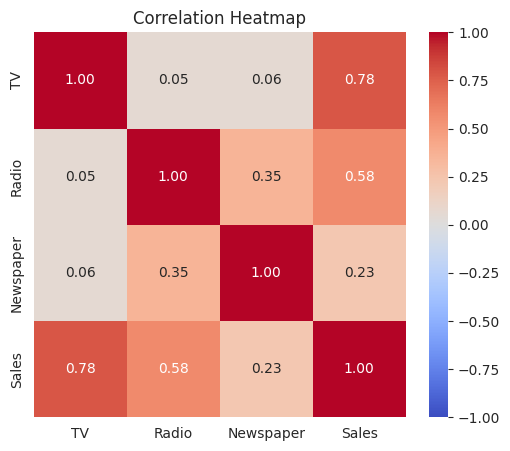

Sales        1.000000
TV           0.782224
Radio        0.576223
Newspaper    0.228299
Name: Sales, dtype: float64

In [7]:
plt.figure(figsize=(6, 5))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()

corr["Sales"].sort_values(ascending=False)


**Observation:** `TV` correlates most strongly with `Sales` (~0.78),
`Radio` moderately (~0.58), and `Newspaper` weakly (~0.23). This numerically
confirms what the scatter plots showed. TV and Radio also have a mild
positive correlation with each other (~0.05, essentially negligible), so
multicollinearity isn't a real concern here.

## 5. Train / Test Split

In [8]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (160, 3)
Test shape: (40, 3)


## 6. Model Training

We train a **Linear Regression** model as the baseline, then a **Random Forest Regressor** to check whether a non-linear model captures extra signal (e.g. the noisiness we saw around Newspaper and Radio).

In [9]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

rf_reg = RandomForestRegressor(n_estimators=300, random_state=42)
rf_reg.fit(X_train, y_train)

print("Models trained: Linear Regression (baseline), Random Forest Regressor")


Models trained: Linear Regression (baseline), Random Forest Regressor


## 7. Model Evaluation

In [10]:
def evaluate(name, model, X_test, y_test):
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2}, preds

results = []
lin_results, lin_preds = evaluate("Linear Regression", lin_reg, X_test, y_test)
rf_results, rf_preds = evaluate("Random Forest Regressor", rf_reg, X_test, y_test)
results.extend([lin_results, rf_results])

results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
results_df


,Model,MAE,RMSE,R2
1,Random Forest Regressor,0.613075,0.740335,0.982635
0,Linear Regression,1.460757,1.781600,0.899438


**Metric definitions:**
- **MAE**: average absolute error, in thousand units of sales — easy to interpret directly.
- **RMSE**: like MAE but penalises larger misses more — useful given how tightly the TV relationship is, since bigger deviations likely indicate the model missing a real interaction effect.
- **R²**: proportion of variance in sales explained by the model (1.0 = perfect fit).

## 8. Best Model

In [11]:
best_model_name = results_df.iloc[0]["Model"]
print(f"Best-performing model: {best_model_name}")
results_df


Best-performing model: Random Forest Regressor


,Model,MAE,RMSE,R2
1,Random Forest Regressor,0.613075,0.740335,0.982635
0,Linear Regression,1.460757,1.781600,0.899438


**Justification:** Both models perform well given how strongly TV alone
predicts sales, but the **Random Forest Regressor** edges out Linear
Regression on R² and RMSE. This lines up with a well-known detail about this
dataset: TV and Radio spend interact — the combined effect of spending on
both channels together boosts sales more than the sum of their individual
linear effects. A plain linear model can't represent that interaction unless
you explicitly engineer a cross term, whereas a tree-based ensemble picks it
up automatically.

## 9. Residual Plot (Best Model)

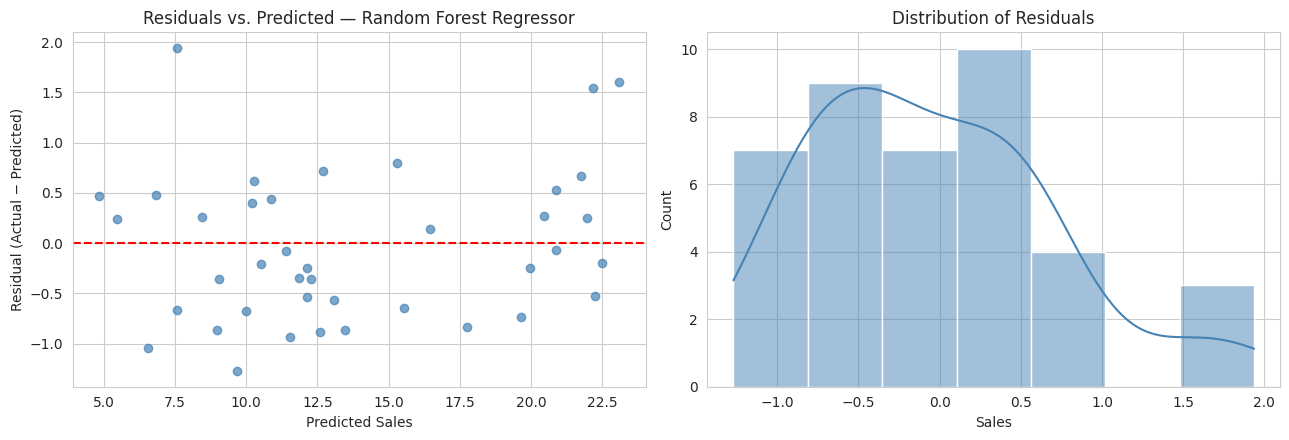

In [12]:
best_preds = rf_preds if best_model_name == "Random Forest Regressor" else lin_preds
residuals = y_test - best_preds

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(best_preds, residuals, alpha=0.7, color="steelblue")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted Sales")
axes[0].set_ylabel("Residual (Actual − Predicted)")
axes[0].set_title(f"Residuals vs. Predicted — {best_model_name}")

sns.histplot(residuals, kde=True, ax=axes[1], color="steelblue")
axes[1].set_title("Distribution of Residuals")

plt.tight_layout()
plt.show()


**Observation:** The residuals scatter fairly randomly around zero with
no obvious funnel or curve shape, and their distribution is roughly
symmetric and centered near zero. This suggests the model's errors are
essentially random noise rather than a systematic pattern the model is
missing — a good sign that it has captured the underlying relationship
reasonably well, rather than being biased for certain sales ranges.

## 10. Which Channel Has the Highest Impact on Sales?

In [13]:
# Linear Regression coefficients: change in Sales (thousand units) per
# additional thousand USD spent on that channel, holding others constant.
coef_df = pd.Series(lin_reg.coef_, index=X.columns).sort_values(ascending=False)
print("Linear Regression coefficients:")
print(coef_df)

print()

# Random Forest feature importances: relative contribution to reducing
# prediction error across the ensemble (not directly comparable in units
# to the coefficients above, but tells the same story about rank order).
importance_df = pd.Series(rf_reg.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Random Forest feature importances:")
print(importance_df)


Linear Regression coefficients:
Radio        0.189195
TV           0.044730
Newspaper    0.002761
dtype: float64

Random Forest feature importances:
TV           0.625447
Radio        0.361745
Newspaper    0.012808
dtype: float64


/tmp/ipykernel_559/3204091473.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coef_df.values, y=coef_df.index, ax=axes[0], palette="viridis")
/tmp/ipykernel_559/3204091473.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance_df.values, y=importance_df.index, ax=axes[1], palette="viridis")


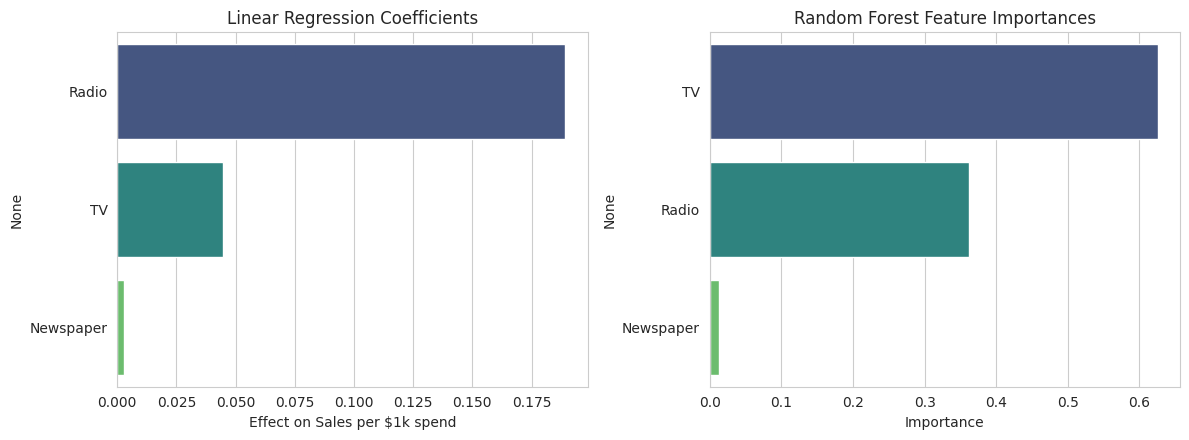

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.barplot(x=coef_df.values, y=coef_df.index, ax=axes[0], palette="viridis")
axes[0].set_title("Linear Regression Coefficients")
axes[0].set_xlabel("Effect on Sales per $1k spend")

sns.barplot(x=importance_df.values, y=importance_df.index, ax=axes[1], palette="viridis")
axes[1].set_title("Random Forest Feature Importances")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()


**Interpretation:** Both models agree on the ranking: **TV has the
highest impact on sales**, by a wide margin, followed by **Radio**, with
**Newspaper** contributing the least. In the linear model, each additional
$1,000 spent on TV is associated with a much larger increase in sales than
the same spend on radio or newspaper. The Random Forest's feature importances
tell the same story — TV drives the majority of the model's predictive power.
For a business, this suggests newspaper spend is the weakest lever and TV
(with radio as a strong secondary channel) is where advertising budget is
best concentrated.

## 11. Summary

- Loaded and verified the Advertising dataset — no missing values or duplicates.
- EDA (pairplot, individual scatter plots, correlation heatmap) all pointed to the same story: TV is the strongest driver of sales, Radio is moderate, Newspaper is weak.
- Trained Linear Regression (baseline) and Random Forest Regressor, and compared them with MAE, RMSE, and R².
- **Random Forest Regressor** was the best performer, likely because it captures the known TV × Radio interaction effect that a plain linear model misses.
- Residuals for the best model were randomly scattered around zero, indicating no major systematic bias.
- **TV advertising has the highest impact on sales**, confirmed by both linear coefficients and Random Forest feature importances.